# Bài tập về nhà Kmeans

## Mục tiêu

- Tự viết lại code cho giải thuật K-means
- Hiểu sâu hơn giải thuật K-means qua việc tự viết lại code
- Ứng dụng mô hình tự viết vào các bài toán đã ra trên lớp

## Dữ liệu

Giống dữ liệu của bài thực hành trên lớp (dữ liệu sinh ngẫu nhiên bằng sklearn và ảnh bird_small.png)

## Yêu cầu

Code K-means tự viết cho kết quả tương đương (không cần giống hệt) với giải thuật của thư viện sklearn khi áp dụng cho dữ liệu sinh ngẫu nhiên và dữ liệu ảnh.


# Các bước làm


## Các thư viện sử dụng


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances

## Chuẩn bị dữ liệu

- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm
  - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên giống nhau giữa các máy tính
- Mỗi điểm dữ liệu có 2 chiều


In [ ]:
n_samples = 100
random_state = 170
center_points = [
    [1, 1],
    [-1, -1],
    [1, -1],
]  # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định
# center_points = 3                           # tâm cụm được chọn ngẫu nhiên

X, y = make_blobs(
    n_samples=n_samples,
    random_state=random_state,
    centers=center_points,
    cluster_std=0.6,
)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:6])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]
 [ 2.67199591 -0.16659988]]


**Vẽ các điểm ảnh sử dụng matplotlib**


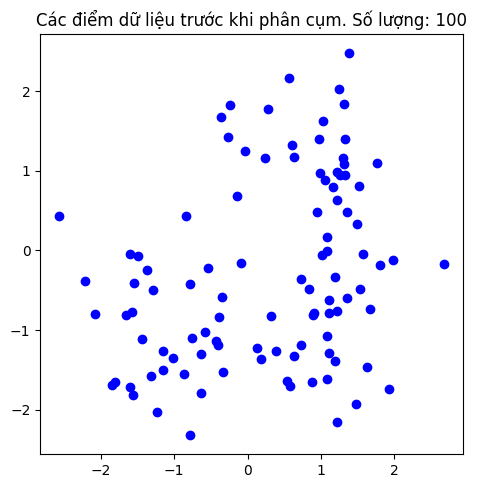

In [3]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(
    X[:, 0], X[:, 1], c="blue"
)  # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

## Tự xây dựng giải thuật K-means:

Viết code cho giải thuật K-means tại mục này


In [4]:
import numpy as np


class CustomKMeans:
    def __init__(self, n_clusters=8, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        # Randomly choose initial centers from data points
        random_idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.cluster_centers_ = X[random_idx]

        for i in range(self.max_iter):
            # Compute distances using broadcasting (N, 1, d) - (1, K, d)
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)

            # Assign labels
            new_labels = np.argmin(distances, axis=1)

            # Compute new centers
            new_centers = np.array(
                [X[new_labels == k].mean(axis=0) for k in range(self.n_clusters)]
            )

            # Check for convergence
            if np.all(self.cluster_centers_ == new_centers):
                self.labels_ = new_labels
                break

            self.cluster_centers_ = new_centers
            self.labels_ = new_labels

        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        return np.argmin(distances, axis=1)


## Kiểm tra giải thuật K-means tự viết cho dữ liệu sinh ngẫu nhiên


- Áp dụng giải thuật K-means tự viết cho tập dữ liệu đã sinh ngẫu nhiên ở trên
- Quan sát kết quả và so sánh với giải thuật của sklearn


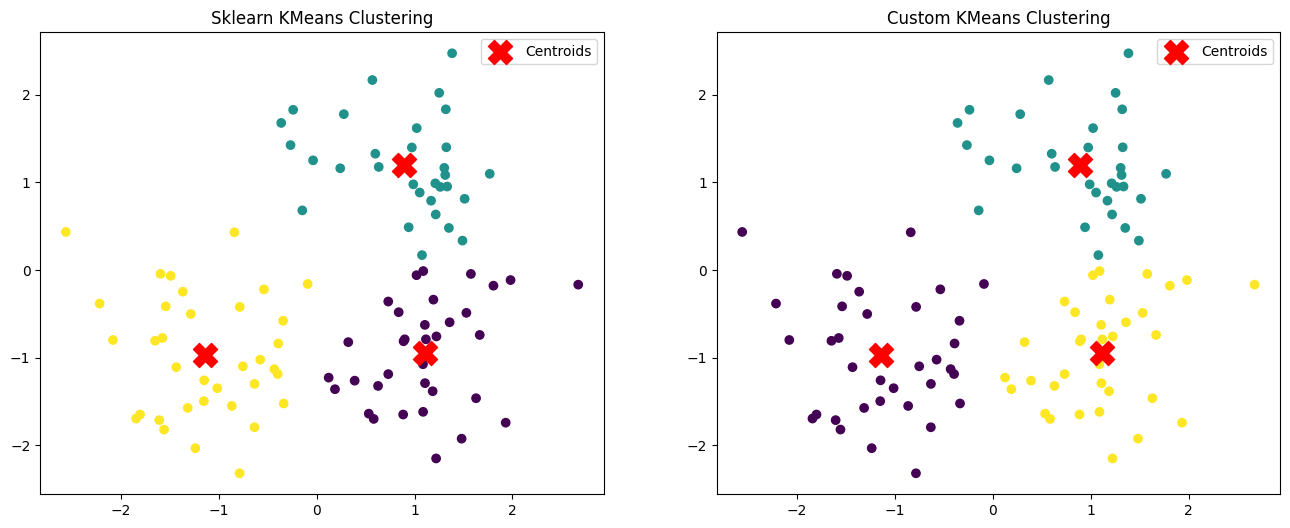

In [5]:
# Initialize both models
sklearn_kmeans = KMeans(n_clusters=3, random_state=170, n_init="auto")
custom_kmeans = CustomKMeans(n_clusters=3, random_state=170)

# Fit models
sklearn_kmeans.fit(X)
custom_kmeans.fit(X)

# Plotting side by side
plt.figure(figsize=(16, 6))

# Sklearn Result
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=sklearn_kmeans.labels_, cmap="viridis")
plt.scatter(
    sklearn_kmeans.cluster_centers_[:, 0],
    sklearn_kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids",
)
plt.title("Sklearn KMeans Clustering")
plt.legend()

# Custom Result
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=custom_kmeans.labels_, cmap="viridis")
plt.scatter(
    custom_kmeans.cluster_centers_[:, 0],
    custom_kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids",
)
plt.title("Custom KMeans Clustering")
plt.legend()

plt.show()

## Ứng dụng K-means tự viết vào nén ảnh


### Thư viện sử dụng - hỗ trợ hình ảnh


In [6]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.display import Image, display

### Đọc dữ liệu hình ảnh

- Mỗi điểm ảnh là 1 mẫu quan sát
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn


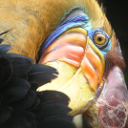

Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [7]:
path_img = "bird_small.png"
display(Image(path_img, width=250, unconfined=True))
img = io.imread(path_img)
data_img = (img / 255.0).reshape(
    -1, img.shape[2]
)  # chuyển ma trận 128x128x3 về mảng 2 chiều
img_shape = img.shape

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

### Nén ảnh bằng giải thuật K-means tự viết


- Tạo file nén ảnh bằng giải thuật K-means tự viết
- Hiển thị kết quả của giải thuật tự viết và giải thuật của sklearn để so sánh


Ví dụ


Ảnh nén bằng K-means tự viết


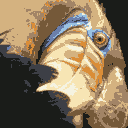

Ảnh nén bằng K-means của thư viện 


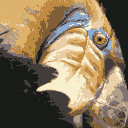

Ảnh gốc


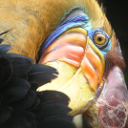

In [8]:
print("Ảnh nén bằng K-means tự viết")
display(Image("img_128.png", width=250, unconfined=True))  # kết quả tự cài đặt
print("Ảnh nén bằng K-means của thư viện ")
display(Image("img128.png", width=250, unconfined=True))  # kết quả của thư viện
print("Ảnh gốc")
display(Image(path_img, width=250, unconfined=True))

Compressing using CustomKMeans with K=16...
Compressing using Sklearn KMeans with K=16...


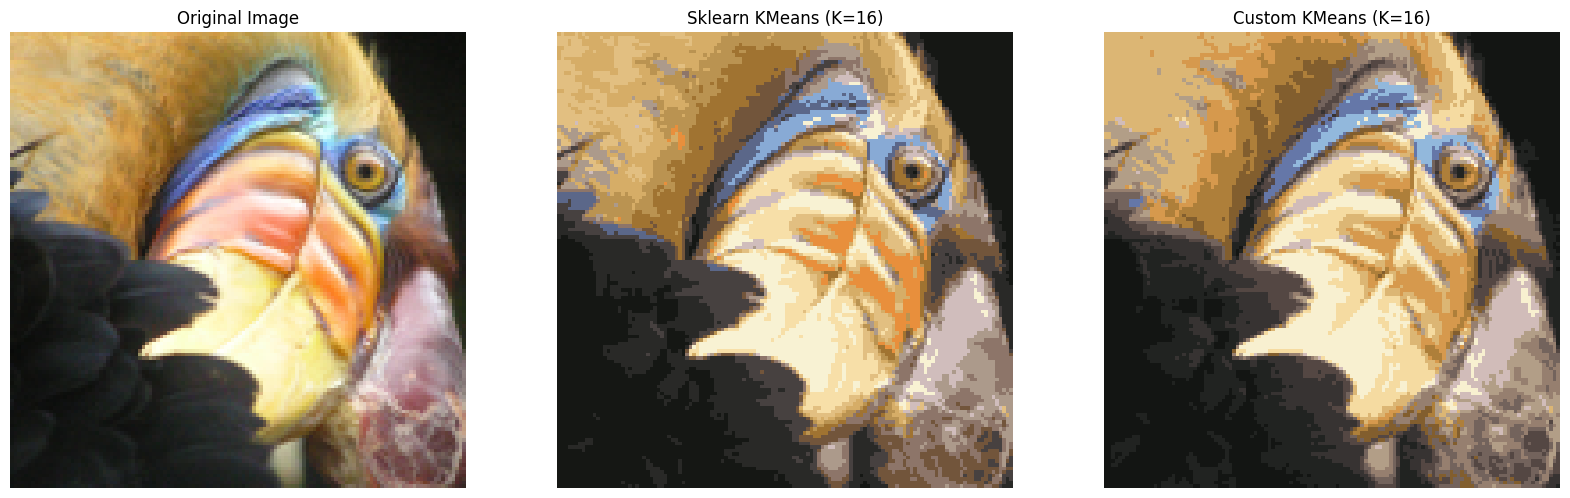

In [9]:
k_colors = 16

# 1. Custom KMeans compression
print(f"Compressing using CustomKMeans with K={k_colors}...")
custom_kmeans_img = CustomKMeans(n_clusters=k_colors, max_iter=100, random_state=42)
custom_kmeans_img.fit(data_img)
custom_compressed_img = custom_kmeans_img.cluster_centers_[custom_kmeans_img.labels_]
custom_compressed_img = custom_compressed_img.reshape(img_shape)

# 2. Sklearn KMeans compression
print(f"Compressing using Sklearn KMeans with K={k_colors}...")
sklearn_kmeans_img = KMeans(n_clusters=k_colors, random_state=42, n_init="auto")
sklearn_kmeans_img.fit(data_img)
sklearn_compressed_img = sklearn_kmeans_img.cluster_centers_[sklearn_kmeans_img.labels_]
sklearn_compressed_img = sklearn_compressed_img.reshape(img_shape)

# 3. Plotting Original, Sklearn and Custom
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sklearn_compressed_img)
plt.title(f"Sklearn KMeans (K={k_colors})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(custom_compressed_img)
plt.title(f"Custom KMeans (K={k_colors})")
plt.axis("off")

plt.show()